<a href="https://colab.research.google.com/github/thamirisbalbi/AnaliseDados/blob/main/C%C3%B3pia_de_RKFehlberg_Exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

### Exercício 1
Resolva o seguinte problema de valor inicial
	\begin{align*}
	y' &= sen(t) + e^{-t} \nonumber\\
	y(0) &= 0 \nonumber\\
	t &\in [0, 1]
	\end{align*}
utilizando o método Runge-Kutta-Fehlberg, com $TOL = 10^{-4}$, $h_{max} = 0.25$ e $h_{min} = 0.02$. Compare o resultado com o solução exata ou solução obtida com a função odeint.

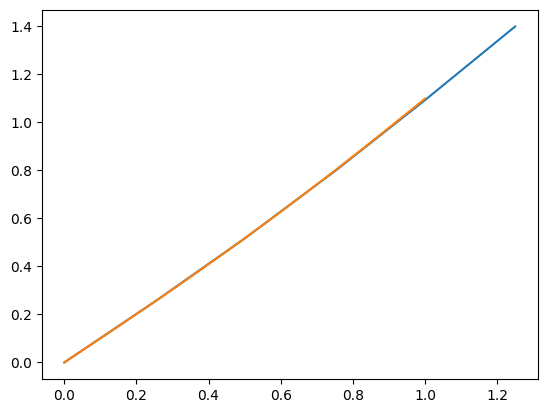

In [ ]:
a = 0 #t0
b = 1
h_max = 0.25
h_min = 0.02
tol = 1e-4
f = lambda t,y: np.sin(t) + np.exp((-t))
y0 = 0


def r_k_f(a, b, y0, tol,h_max,h_min, f): #t,w,h saida, w aprox yt e passo h foi usado
  t = [a]
  w = [y0]

  h = h_max
  flag = 1
  i = 0
  while flag == 1:
    tn = t[-1]
    #wn = w[-1]
    k1 = h*f(tn,w)
    k2 = h*f(tn + (h/4), w[-1] + (k1/4))
    k3 = h*f(tn + ((3*h)/8), w[-1] + (3/32) * k1 + (9/32)*k2)
    k4 = h*f(tn + ((12*h)/13), w[-1] + (1932/2197)*k1 - (7200/2197)*k2 + (7296/2197)*k3)
    k5 = h*f(tn + h, w[-1] + (439/216)*k1 - 8*k2 + (3680/513)*k3 - (845/4104)*k4)
    k6 = h*f(tn + h/2, w[-1] - (8/27)*k1 + 2*k2 - (3544/2565)*k3 + (1859/4104)*k4 - (11/40)*k5)

    #erro r:
    r = (abs((1/360)*k1 - (128/4275)*k3 - (2197/75240)*k4 + (1/50)*k5 + (2/55)*k6))/h

    if r <= tol:
      t.append(tn+h)
      w.append((w[-1] +(25/216)*k1 + (1408/2565)*k3 + (2197/4104)*k4 - (1/5)*k5))

    #calcular q:
      q = 0.84*(tol/r)**(1/4)

      if q <= 0.1:
        h = 0.1 * h
      elif q >= 4:
        h = 4*h
      elif (tn+h) > b:
        h = b - tn
      else:
        h = q*h

      if h > h_max:
        h = h_max

      if tn >= b:
        flag = 0

      elif h < h_min:
        flag = 0
        print("h mínimo ultrapassado!")
  return t,w,h
t,w,h = r_k_f(a,b,y0,tol,h_max,h_min,f)
plt.plot(t,w)

t2 = np.linspace(0,1,1001)

def func(t,y):

  dydt = np.sin(t) + np.exp((-t))

  return dydt

sol = odeint(func,y0, t2)
plt.plot(t2,sol)
